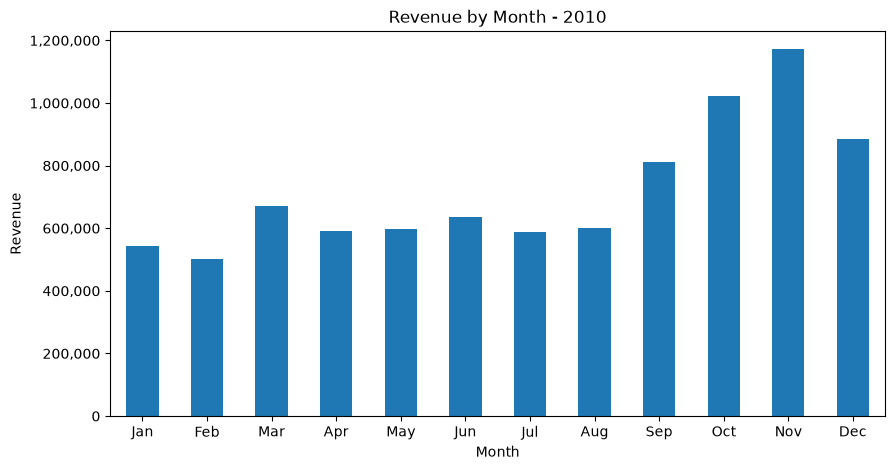

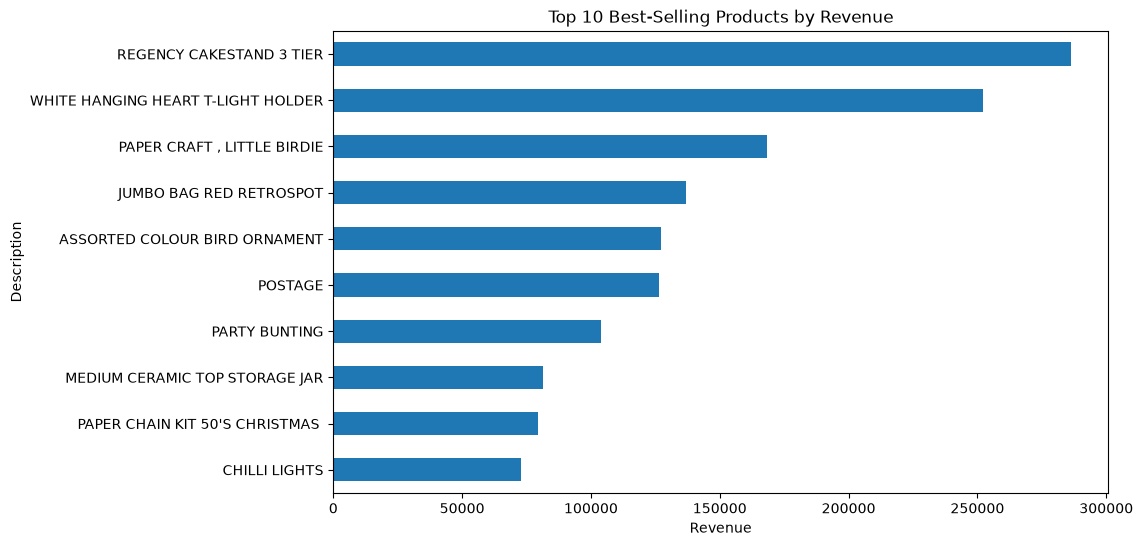

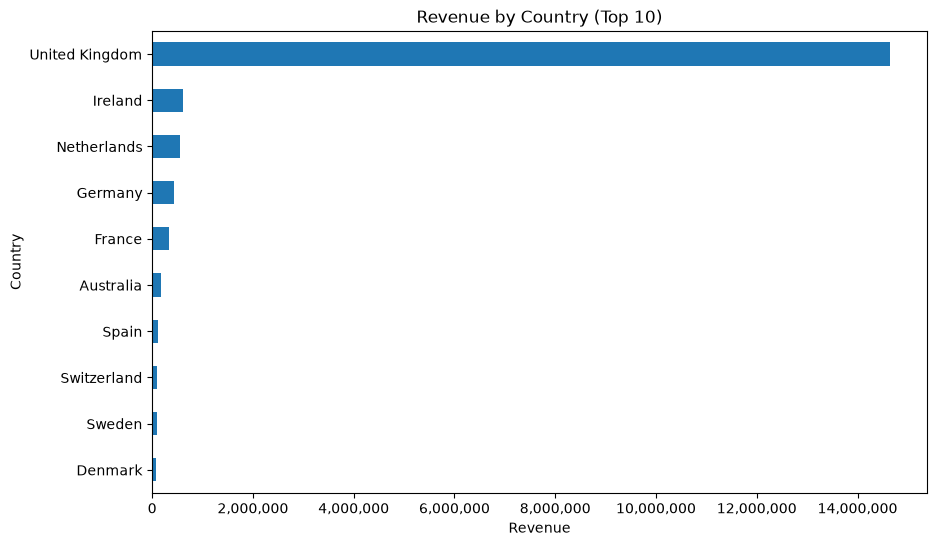

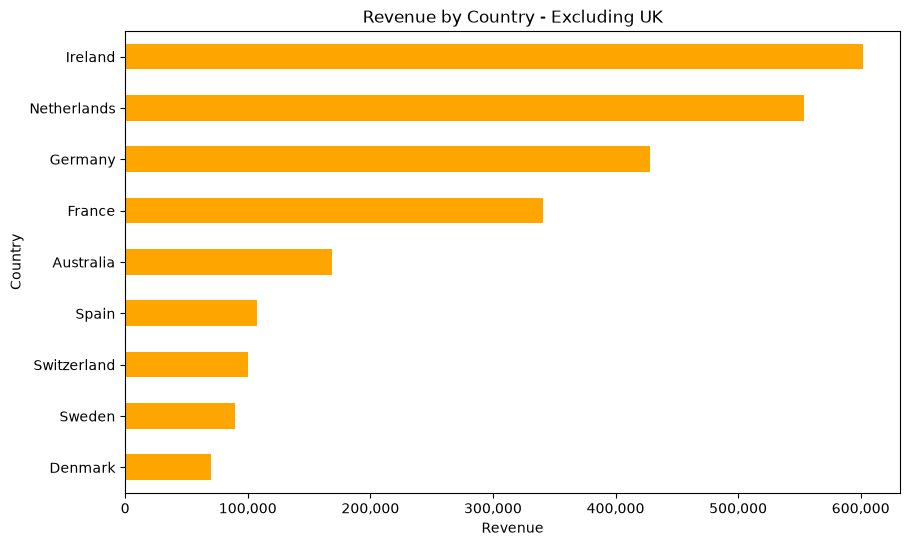

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # tick formatting
import calendar # for formatting the monthly revenue

sales = pd.read_csv('../data/sales_cleaned.csv')
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])
# dates reset to text everytime

exclude_description = ['Manual', 'Postage'] # not an actual product
sales = sales[~sales['Description'].isin(exclude_description)]

# replaces Eire to Ireland
sales['Country'] = sales['Country'].replace('EIRE', 'Ireland')

year_filter = 2010
sales_year = sales[sales['Year'] == year_filter]

monthly_revenue = sales_year.groupby('Month')['Revenue'].sum()
# replace the numerical value to abbreviation  
monthly_revenue.index = [calendar.month_abbr[m] for m in monthly_revenue.index]

monthly_revenue.plot(kind='bar', figsize=(10, 5)) # plot the values of monthly revenue as bar chart
plt.title(f'Revenue by Month - {year_filter}') # label for the chart
plt.xlabel('Month') # label for x axis
plt.ylabel('Revenue') # label for y axis
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.show() # displays chart

top_products = sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
# sales[~sales['Description'].isin(exclude_description)] - filters out Description that is in exclude_description
# groupby('Description') - group rows with same name and totals the revenue
# sort_values(ascending=False) - sort from high to low
# head(10) - get the top 10

top_products.plot(kind='barh', figsize=(10,6)) # barh - horizontal bar chart
plt.title('Top 10 Best-Selling Products by Revenue')
plt.xlabel('Revenue')
plt.gca().invert_yaxis() # puts the top product to the 1st position
plt.show()

# print(sales[['Country', 'Month', 'Year', 'Quantity', 'Price', 'Revenue']].head())
revenue_by_country = sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

# with UK
revenue_by_country.plot(kind='barh', figsize=(10,6))
plt.title('Revenue by Country (Top 10)')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
# formats the xaxis to show plain numbers instead of scientific notation
plt.show()

# without UK
revenue_by_country.drop('United Kingdom').plot(kind='barh', figsize=(10,6), color='orange')
plt.title('Revenue by Country - Excluding UK')
plt.xlabel('Revenue')
plt.gca().invert_yaxis()
# formats the xaxis to show plain numbers instead of scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.show()